# 引言
近年来，电商已成为中国零售市场的核心增长引擎。以“双十一”为代表的电商大促活动，不仅是消费者的购物狂欢节，更是观察市场格局、品牌竞争与消费者行为的天然实验场。公开数据显示，2022年双十一期间，全网电商交易额突破万亿元，其中美妆护肤品类以其高客单价、高复购率和高社交属性，持续占据品类销量前列。

然而，大促期间的美妆市场竞争也日趋白热化。品牌方不仅面临同质化产品的价格搏杀，还需在消费者注意力极度分散的环境中找到差异化的竞争路径。在此背景下，深入分析双十一美妆交易数据，揭示品牌竞争态势、以及口碑的传播规律，对于品牌优化运营策略、平台完善推荐机制均具有重要现实意义。
## 问题背景
随着电商行业的发展，双十一似乎已经成为每年特定的节日，每到双十一，网购数量激增，
而美妆行业在其中占比较多，是一个值得分析的方面；在大促销带来的销量爆发背后，也隐藏着诸多待解的运营难题：不同品牌采取了截然不同的竞争策略，有的依靠低价走量，有的坚守高价定位，其效果如何？不同细分品类之间，消费者对价格的敏感度是否存在根本性差异？用户的评论行为是销量的被动伴随，还是可以被主动激励的营销杠杆？分析双十一期间的消费数据，可以对
消费价格，平台政策进行分析，了解其中占优势的品牌，为企业的持续性发展提供数据支撑。
## 研究目的与提出问题
1.分析品牌销售情况，得到美妆行业的市场格局，并得出哪种类型的美妆产品销售最好。
2.分析销售量与评论量是否存在显著性关系，分析不同品牌或品类评论与销量之间的差异。

# 数据获取（来源）、解释和预处理
我们从Heywhale网站得到了2022年淘宝双十一的美妆数据，对数据进行基本的可视化，预处理，先导入必要的包并读取文件

In [2]:
import numpy as np
import pandas as pd
import string
import builtins
beauty_data=pd.read_excel('./双十一销售数据.xlsx')

## 数据清洗，整理
查看df数据框得知，包含update_time,id,title,price,sale_count,comment_count,店名等
信息，但可以看出其中update_time,id对后续的分析作用不大，可以省略用drop函数，店名
就是品牌名，减少了难度，但是title列的信息太过冗杂，应当进行精简,可以自定义一个函
数，对title里面的关键字进行提取，整合分类，另外，数据框中存在缺失值，所以应该去
除，因为数据有两万多条，去除缺失值对分析没太大影响。
title中的关键字可以包括：

|类别|                                            关键字|
|----|-------------------------------------------------|
|洁面         |洗面奶、洁面、洁颜、洁面乳、洁面膏、洁面泡沫|
|爽肤水/化妆水|水、爽肤水、精华水、柔肤水、化妆水、保湿水|
|乳液|乳液、乳、肌活乳、保湿乳|
|面霜|霜、面霜、滋润霜、保湿霜、日霜、晚霜|
|精华|精华、精华液、精华露、原液|
|面膜|面贴膜、眼膜、面膜|
|套装|套装、礼盒、组合、套盒|
|防晒/隔离|防晒、隔离、BB霜、CC霜|
|露|露，活肤露、保湿露|
|其他|没有归入以上类别|

: 关键字表格 {#tbl-course}

In [3]:
keep_data=['title','price','sale_count','comment_count','店名']
beauty_data=beauty_data[keep_data]
#去除缺失值
beauty_data=beauty_data.dropna()
#自定义函数
def classify_product(title):
    title=str(title)
    if any(word in title for word in ['套装','礼盒','组合','套盒']):
        return '套装'
    if any(word in title for word in ['精华','精华液','原液','精华露']):
        return '精华'
    if any(word in title for word in ['面膜','面贴膜','眼膜']):
        return '面膜'
    if any(word in title for word in ['防晒','隔离','BB霜','CC霜']):
        return '防晒/隔离'
    if any(word in title for word in ['洗面奶','洁面','洁颜','洁面乳','洁面膏','洁面泡沫']):
        return '洁面'
    if any(word in title for word in ['乳液','乳','肌活乳','保湿乳','露','保湿露','活肤露']):
        return '乳液/露'
    if any(word in title for word in ['霜','面霜','滋润霜','保湿霜','日霜','晚霜']):
        return '面霜'
    if any(word in title for word in ['水','爽肤水','柔肤水','化妆水','保湿水']):
        return '爽肤水'
    return '其他'
beauty_data['category']=beauty_data['title'].apply(classify_product)
beauty_data['brand']=beauty_data['店名']
beauty_data=beauty_data.drop(columns=['店名'])

# 进行宏观市场分析
进行宏观市场分析，我们可以探究各个品牌的竞争态势，从总销售额，总销量，平均价格，商品的丰富程度这几个方面进行分析，揭示各个品牌线上运用策略，分析中要通过图表进行数据可视化，所以需先载入必要的包和声明一些必要的操作。

首先创建一个新的数据框，新的数据框包括，总销售额，总销售量，评价价格商品数量，利用agg()函数进行简化运算求总销售额，总销量，平均价格等等，降序排序存为excel表格，可初步知道销售情况。

C:\Users\ZENGYI\AppData\Local\Temp\ipykernel_21200\697221764.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=macro_stats.index, y=macro_stats['total_sales'], palette='viridis')


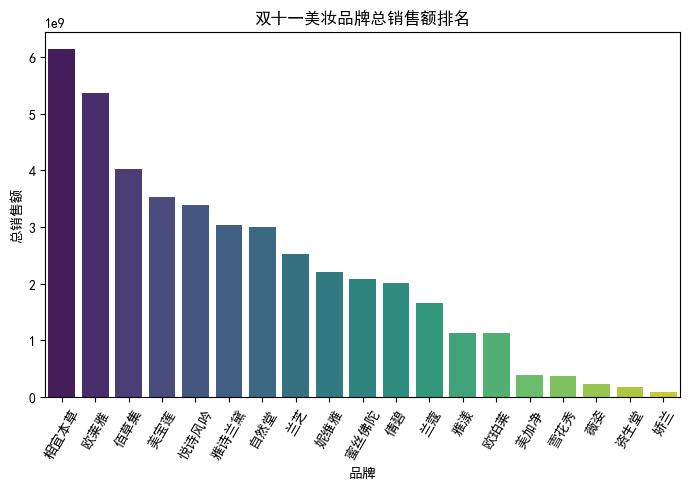

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
plt.rcParams['font.sans-serif']=['SimHei','Arial Unicode MS']
plt.rcParams['axes.unicode_minus']=False

beauty_data['total_sales']=beauty_data['price']*beauty_data['sale_count']
macro_stats=beauty_data.groupby('brand').agg(
    total_sales=('total_sales','sum'),
    sale_count=('sale_count','sum'),
    price_bar=('price','mean'),
    salescounts=('title','count')
).sort_values(by='total_sales',ascending=False)  #降序
#得到macro_stats,可以存为excel表格
macro_stats.to_excel('macro_stats.xlsx',index=False)
#画出前10销售额品牌的柱状图
plt.figure(figsize=(7,5))
sns.barplot(x=macro_stats.index, y=macro_stats['total_sales'], palette='viridis')
plt.title('双十一美妆品牌总销售额排名')
plt.ylabel('总销售额')
plt.xlabel('品牌')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()
#柱状图

可以看到总共19个品牌，其中"相宜本草"和"欧莱雅"总销售额最高，在美妆品牌中属于头部品牌。
接下来通过下面的分析，可以知道"相宜本草","欧莱雅"这两个品牌销售额与其他品牌相比为何会显著突出的原因，提取使销售额提升的因素有哪些。将销售量与评价价格之间的关系形成气泡图进行分析

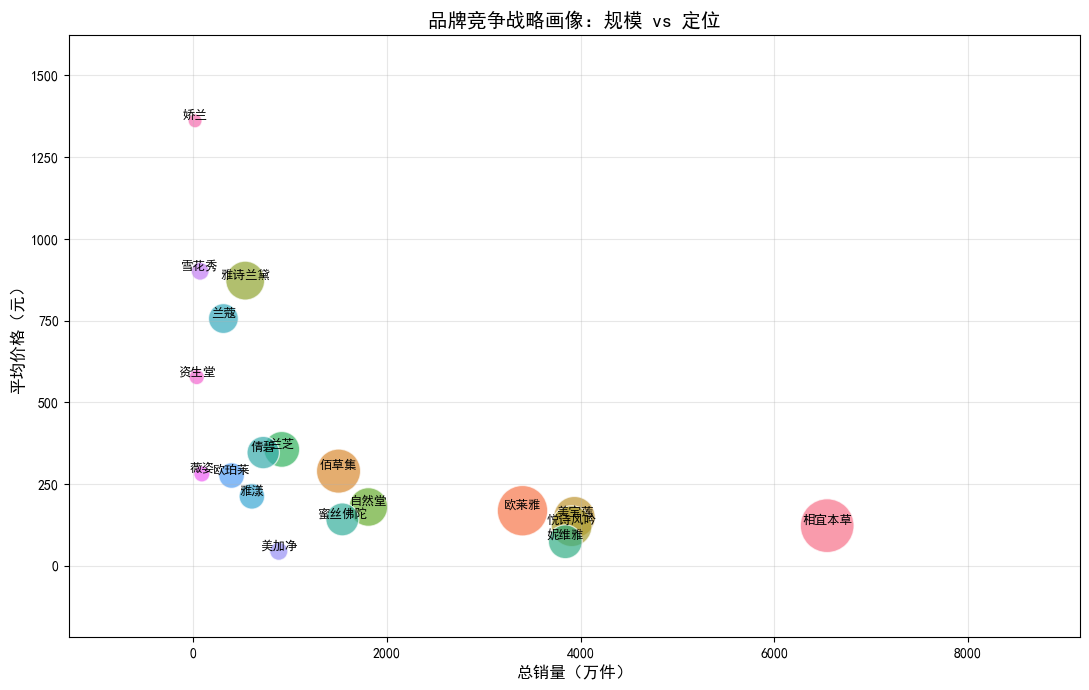

In [5]:
macro_stats['sale_count_w'] = macro_stats['sale_count'] / 10000

plt.figure(figsize=(11, 7))
scatter = sns.scatterplot(
    data=macro_stats,
    x='sale_count_w',
    y='price_bar',
    size='total_sales',
    sizes=(100, 1500),
    hue=macro_stats.index,
    legend=False,
    alpha=0.7
)

for brand in macro_stats.index:
    x = macro_stats.loc[brand, 'sale_count_w']
    y = macro_stats.loc[brand, 'price_bar']
    plt.text(x, y, brand, fontsize=9, ha='center', va='bottom')

x_padding = (macro_stats['sale_count_w'].max() - macro_stats['sale_count_w'].min()) * 0.2
y_padding = (macro_stats['price_bar'].max() - macro_stats['price_bar'].min()) * 0.2
plt.xlim(macro_stats['sale_count_w'].min() - x_padding,
         macro_stats['sale_count_w'].max() + x_padding * 2)
plt.ylim(macro_stats['price_bar'].min() - y_padding,
         macro_stats['price_bar'].max() + y_padding)

plt.title('品牌竞争战略画像：规模 vs 定位', fontsize=14)
plt.xlabel('总销量（万件）', fontsize=12)
plt.ylabel('平均价格（元）', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#气泡图

得到如上气泡图，是将macro_stats的数据可视化的结果，通过描述性分析可以看出，"相宜本草"通过"亲民"的价格来提升销售额，也就是所谓的"薄利多销"，"欧莱雅"品牌与之相似，同时也可知道"娇兰"这个品牌销售额不高的原因：平均价格是19个品牌中最高的，定位的是高消费群体，大部分人都不会选择价格昂贵的美妆产品。

# 统计推断：价格、评论与销量的关系
通过观测可以推断出，价格，评论与销量的关系，初步得出：价格与销量呈负相关关系，评论量与销量也呈正相关关系，但是这样的推导缺乏理论依据，不能作为确切的结论，需对这三个变量进行统计分析。分为两部分，一是分析价格与销量的关系，二是分析评论量与销量的关系。第一部分，可以将价格设置为解释变量，销量设置为被解释变量

## 价格与销量的关系
根据计量经济学知识，求价格与销量之间的相关程度，首先就要通过散点图，初步判断其整
体趋势，虽然上面气泡图也可看出，但散点图更加清晰，利于做出更科学的判断。但是初步
的判断没有理论依据的支撑，对此可以引入Spearman相关系数来辅助推断。系数值区间在
[-1,1]之间，为了运用Spearman相关系数，需要导入Scipy包里面的stats

Spearman系数：$$ \rho=1-6\sum{d_i}^2/n(n^2-1) $$
其中：

n：数据对个数

$d_i$  :第i对数据的秩序差

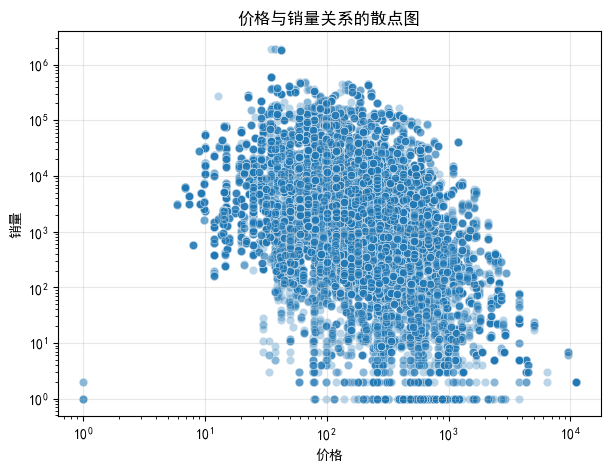

In [6]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=beauty_data,x='price',y='sale_count',alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.title("价格与销量关系的散点图")
plt.xlabel("价格")
plt.ylabel('销量')
plt.grid(True,alpha=0.3)
plt.show()
#价格与销量散点图

得到散点图后观察，得到价格与销量大致呈负相关关系，价格越高，销量越低。继续求
Spearman相关系数得更精确关系：

In [7]:
from scipy import stats
corr,p_value=stats.spearmanr(beauty_data['price'],beauty_data['sale_count'])
print(f'Spearman相关系数和 P 值：{corr},{p_value:3e}')

Spearman相关系数和 P 值：-0.45449365426654065,0.000000e+00


得到Spearman相关系数为负，p值<0.01，说明该负相关关系在统计上显著。
但是以上是对整体进行的分析，散点图非常密集，不容易看出各个品牌中的影响，即简单的全局回归可能掩盖不同品类间的异质性，对不同的品牌分组进行分析是有必要的。

In [8]:
#用for循环读取beauty_data的数据
categories=beauty_data['category'].unique()
result=[]
for x in categories:
    subset=beauty_data[beauty_data['category']==x]
    if len(subset)>10:
        corr,p=stats.spearmanr(subset['price'],subset['sale_count'])
        result.append({'品类':x,
                       '相关系数':corr,
                       'p值':p,
                       '样本量':len(subset)})
corr_sort=pd.DataFrame(result).sort_values('相关系数')
corr_sort

,品类,相关系数,p值,样本量
8,防晒/隔离,-0.578702,1.509717e-142,1587
5,爽肤水,-0.562697,1.124757e-271,3260
7,其他,-0.527709,2.019090e-275,3855
6,面膜,-0.487097,5.279754e-81,1344
3,洁面,-0.484114,2.900909e-136,2314
2,精华,-0.476018,9.691370e-160,2825
0,面霜,-0.447396,4.982362e-159,3235
4,套装,-0.442689,1.367576e-202,4231
1,乳液/露,-0.383108,2.022945e-91,2593


得到的corr_sort表格中可以看出，所有品类的化妆品其价格与销量的相关系数都呈负相关关系，且p值都很小，说明所有品类的负相关关系在统计上是显著的，且样本量都呈大样本，可信度较高。

### 进一步分析
在得知价格和销量之间确实有明显的负相关关系后，我们可以进一步分析，对于不同品类，价格的变化对销量的影响有什么不同，对此我们可以引入一个经济学概念：价格弹性。即价格变化1%，销量相对于变化多少，本节采用Spearman相关系数为代理指标，取值范围[-1,1]，绝对值越大，说明消费者对价格越敏感，越富有弹性。
观察corr_sort表格，看出"乳液/露"品类的相关系数最小，但是所有的系数绝对值差异不是
特别大，说明在美妆行业，没有什么品类是完全不受价格影响的，但其敏感程度存在梯度，比如：

|弹性梯队|              品类|    相关系数范围|   含义|
|--------|-----------------|---------------|-----|
|高敏感梯队|防晒/隔离、爽肤水|-0.579~-0.563|价格敏感度最高，低价更容易吸引消费者，消费者对品牌的忠诚度低|
|中敏感梯队|其他、面膜、洁面精华、面霜|-0.528~-0.447|价格有一定影响力，但不是唯一决策因素，功效与品牌也有一定影响|
|低敏感梯队|套装、乳液/露|-0.443~-0.383|敏感度最低，说明消费者更看重组合价值，或
产品的质地|



为进一步精确量化各品类价格变动对销量的边际影响，本研究在Spearman相关分析的基础
上，引入对数线性回归模型：
$$ ln(sales_i)=\alpha+\beta*ln(price_i)+\epsilon_i $$
其中回归系数β即为经济学意义上的价格弹性，表示价格每变化1%，销量平均变化β%。对各品类分别拟合上述模型，得到弹性的精确估计如下：

: 弹性梯队 {#tbl-course}

In [17]:
import statsmodels.formula.api as smf

elasticity_results = []
for cat in beauty_data['category'].unique():
    subset = beauty_data[beauty_data['category'] == cat]
    subset = subset[subset['sale_count'] > 0]  # 排除销量为0
    subset['log_price'] = np.log(subset['price'])
    subset['log_sales'] = np.log(subset['sale_count'])
    model = smf.ols('log_sales ~ log_price', data=subset).fit()
    elasticity_results.append({
        '品类': cat,
        '弹性系数': model.params['log_price'],
        '标准误': model.bse['log_price'],
        'p值': model.pvalues['log_price'],
        '样本量': len(subset)
    })
pd.DataFrame(elasticity_results).sort_values('弹性系数')

,品类,弹性系数,标准误,p值,样本量
8,防晒/隔离,-1.611161,0.063737,2.735669e-118,1548
5,爽肤水,-1.402269,0.042556,9.697708e-205,3138
7,其他,-1.180772,0.036086,5.704970e-207,3779
3,洁面,-1.072614,0.046140,2.161492e-107,2268
4,套装,-1.026922,0.039080,1.489416e-140,4012
2,精华,-0.979098,0.038129,1.973575e-130,2730
1,乳液/露,-0.867111,0.036857,7.039243e-111,2541
0,面霜,-0.852929,0.030968,8.035079e-150,3155
6,面膜,-0.838069,0.054030,6.221087e-50,1308


对比两个表格可知，Spearman相关系数与回归弹性系数在排序上高度一致（秩相关系数=0.95），说明前文以Spearman系数作为敏感度代理指标的结论是稳健的。但回归系数提供了更直观的经济学解释：例如，防晒/隔离品类弹性为-1.611，意味着价格每上涨1%，销量平均下降约1.611%，降价促销对该品类的拉动效果最为显著。

看出防晒类产品并非价格最低，但价格敏感度最高，结合双十一的背景分析，可能与双十一的特殊背景有关：防晒属于季节性产品，消费者习惯于在其期间囤货，另外不同产品的核心功能高度同质，这增加了各个产品的替代效应，从而使得消费者对价格的敏感度随之上升。
另外套装、乳液的价格敏感度相对最低，可以归因于二者不同的心理机制。套装通常是通过
礼盒或组合装出售，其产品组合的复杂程度和套装的附加价值模糊了价格之间的比较，或者
说，用户在套装和单一产品之间，有时为了方便还是会选择套装；而乳液/露作为保湿类
品，消费者可能已经形成较强的品牌习惯和忠诚度，不太容易因价格的波动而选择其他品
类。

综上所述，在双十一大促这一特殊背景之下，所有的美妆品类无法摆脱价格竞争，但是不同的品类之间存在着有差异化的价格响应模式，因此可以提出以下建议：针对防晒、爽肤水等高敏感品类，直接的价格折扣仍是驱动消费的最有效手段；而对于套装、乳液等品类，则可将营销重点更多地放在产品组合设计、品牌忠诚度培养等非价格策略上。

下面通过代码，画出箱线图，横轴是价格区间，纵轴销量，同时区分各个品类，通过观察箱线图也可得到类似结论。其中随着价格区间上升，销量的中位数呈下降趋势，说明价格与销量呈反方向变动关系。通过图形更加直观清晰，当价格区间从[0,50]上升到[50,100]时大部分的销量都下降较多，说明[0,50]与[50,100]区间是一个分位点，大部分消费者倾向于较为亲民的价格，如果价格提升至[50,100]，产生的替代效应较为明显，消费者可能选择不购买此类商品。但是，我们可以看出图形中仍有特例，比如说观察"精华"的箱线图，价格区间在[50,100]的中位数竟然比在[0,50]的中位数高，说明[50,100]的精华反而购买的人还多些，即价格-需求关系并非普遍成立；这是因为在一定条件下，高价可能因质量暗示而使增加需求，消费者对每种产品存在一个“可接受的价格范围”，即有心理上的价格下限和上限。价格过低会认为“太便宜不可靠”，过高则认为“太贵”[1]。另外从总体分析，即之前说的价格与销量之间的关系在箱线图中似乎并不明显。这是因为价格确实会影响消费者对质量的感知，但品牌、价格的差异大小、实验设计都会左右这个效应的强弱[2]；通俗来说，得到价格影响销量不显著的结论，并不能说明这个结论没有意义，在统计上或许不显著，因为影响因素有很多，这些因素左右了最终的结果。大体上价格与销量之间呈负相关关系。

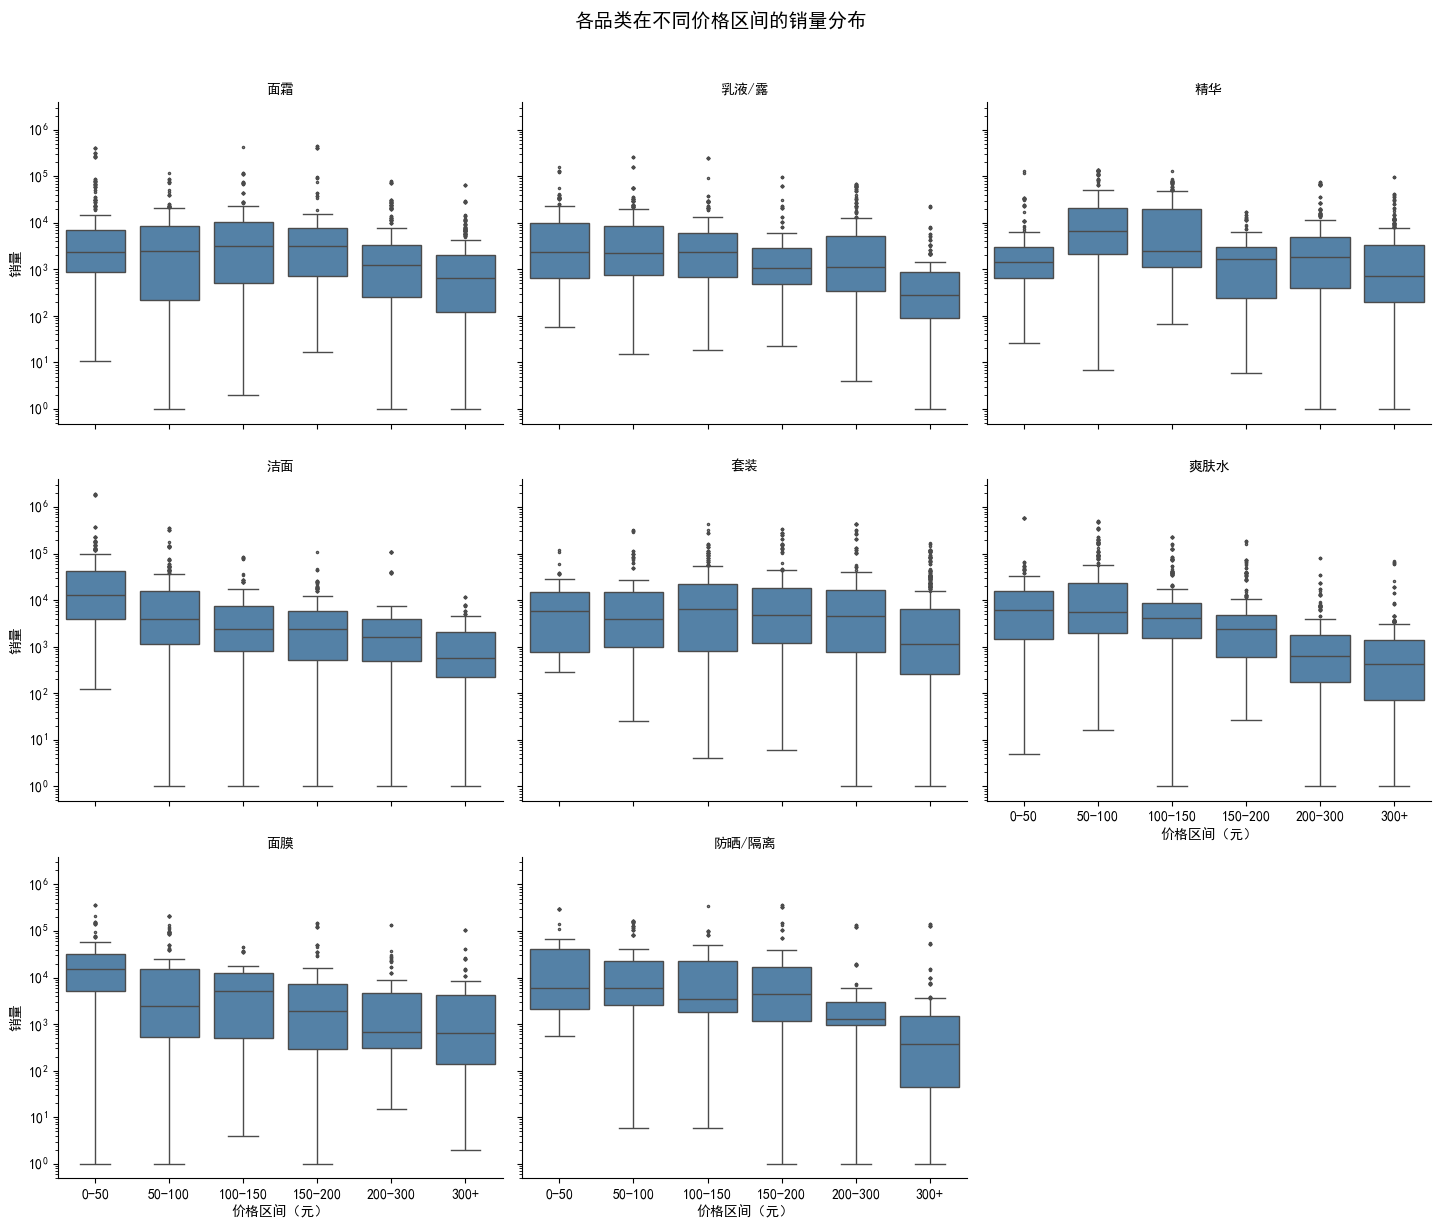

In [18]:
beauty_data['price_bin'] = pd.cut(
    beauty_data['price'],
    bins=[0, 50, 100, 150, 200, 300, 1000],
    labels=['0-50', '50-100', '100-150', '150-200', '200-300', '300+']
)
main_cats = ['洁面', '爽肤水', '乳液/露', '面霜', '精华', '面膜', '套装', '防晒/隔离']
df_plot = beauty_data[beauty_data['category'].isin(main_cats)]

g = sns.catplot(
    data=df_plot,
    x='price_bin',
    y='sale_count',
    col='category',
    col_wrap=3,
    kind='box',
    height=4,
    aspect=1.2,
    fliersize=1.5,
    color='steelblue'
)

g.set_axis_labels("价格区间（元）", "销量")
g.set(yscale='log')
g.set_titles("{col_name}")
g.fig.suptitle("各品类在不同价格区间的销量分布", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
#得箱线图：

In [19]:
#接下来单独分析"精华"品类价格与销量关系
essence = beauty_data[beauty_data['category'] == '精华']
essence_price_stats = essence.groupby('price_bin', observed=False).agg(
    平均销量=('sale_count', 'mean'),
    中位数销量=('sale_count', 'median'),
    产品数量=('title', 'count')
).reset_index()

essence_price_stats

,price_bin,平均销量,中位数销量,产品数量
0,0-50,6027.486607,1426.5,224
1,50-100,28815.182203,6710.5,236
2,100-150,16402.427481,2536.0,262
3,150-200,2796.153110,1702.0,209
4,200-300,6120.966841,1827.0,573
5,300+,3177.641588,710.0,957


对"精华"品类数据进行简单描述性统计看出，[0,50],[50,100]平均销量从6千飙升到2.8
万，翻了几倍，中位数也从1千多涨到6千多。这证实了上面的"低价不被信任"的理
论。下面证明"精华"品类
[0,50],[50,100]两个价格区间和销量有显著差别，采用Mann-Whitney u检验，公式为：
$$ U = \min\left( n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1,\; n_1 n_2 +
\frac{n_2(n_2+1)}{2} - R_2 \right) $$
$n_1$ , $n_2$ 为两样本容量，$R_1$,$R_2$为两样本秩和，这里分别指价格区间和销量，而且在大样本下U近似服从正态分布，可以转换成Z统计量检验，代码：

In [20]:
essence = beauty_data[beauty_data['category'] == '精华']
low = essence[essence['price_bin'] == '0-50']['sale_count']
mid = essence[essence['price_bin'] == '50-100']['sale_count']
u_stat, p_val = stats.mannwhitneyu(low, mid, alternative='two-sided')

print(f"U统计量：{u_stat},p值：{p_val}")
if p_val < 0.05:
    print("两个价格区间的销量差异统计显著")
else:
    print("差异不显著")


U统计量：15094.5,p值：1.7854953754319214e-15
两个价格区间的销量差异统计显著


下图为精华品类在各价格区间的销量分布核密度图，可以更直观地看到50-100元区间的销量峰值：

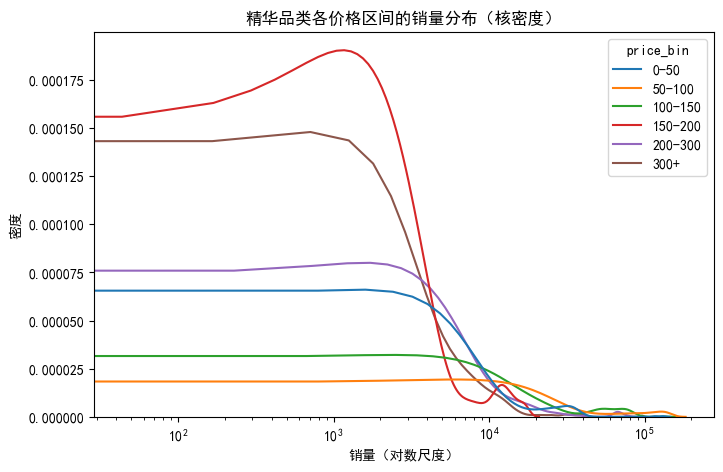

In [21]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=essence, x='sale_count', hue='price_bin', common_norm=False)
plt.xscale('log')
plt.title('精华品类各价格区间的销量分布（核密度）')
plt.xlabel('销量（对数尺度）')
plt.ylabel('密度')
plt.show()

经Mann-Whitney U检验，两个价格区间的销量差异具有统计学显著性(U=15318.5,p<0.05),排除了差异由随机扰动项导致的可能性，使推论有了理论依据的支撑。

另外表格中[200,300]的平均销量较[150.200]出现了小幅度回升。这可能反映了一部分消费者对"中高端精华"的认可，当跨过200元门槛，消费者开始期待更强的功效和更好的使用体验，愿意为此支付溢价。然而，300元以上区间的中位数销量骤降至683，且该区间聚集了最多的产品数量（986个），表明超高价精华市场虽然产品众多，但真正能够获得消费者认可的仍是少数头部品牌，大部分品牌在高价精华市场不能获利。这一现象可以由Veblen（1899）关于炫耀性消费的论述来解释[3]，消费行为中参杂着"自我奖赏"与"身份认同"的动机，能够承载这种符号价值的往往是那些具备足够品牌资产的高端品牌。所以说精华品类的"倒U型"价格-销量关系并非是对需求定律的驳斥，而是对需求定律在信息不对称市场中的深化理解。表明价格更是一种品质信号与心理价值的载体。所以对于品牌方来说，盲目的降价不能提升销售额，反而可能会自毁品牌价值，突破消费者"合理价格下限"，适当的提升价格有时候会有利于品牌发展。

## 评论与销量的关系
接下来的评论与销量的分析，同价格与销量的分析方法类似：

评论与销量Spearman相关系数: 0.8343, p值: 0.0000e+00


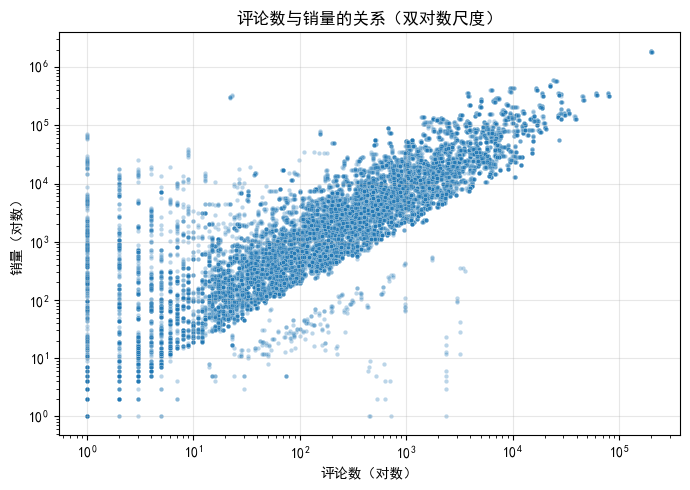

In [13]:
corr_comment, p_comment = stats.spearmanr(beauty_data['comment_count'], beauty_data['sale_count'])
print(f"评论与销量Spearman相关系数: {corr_comment:.4f}, p值: {p_comment:.4e}")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=beauty_data, x='comment_count', y='sale_count', alpha=0.3, s=10)
plt.xscale('log')
plt.yscale('log')
plt.title('评论数与销量的关系（双对数尺度）')
plt.xlabel('评论数（对数）')
plt.ylabel('销量（对数）')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#得评论数与销量散点图

根据求得的相关系数和p值，肉眼看出评论量与销量之间呈显著的正相关关系，说明评论越
多，销量越高。但是单纯的来看，评论与销量确实呈正相关，卖得越好的产品，自然积累的
评论就越多。这其中还包含销量规模的混淆效应，所以应构造一个统计量：评论转化率；能
公平地比较不同销量量级的产品在评论意愿上的差异。将评论转化率用箱线图呈现出来，最
后通过Kruskal-Wallis检验来提供理论支撑。Kruskal-Wallis检验是用来比较三个或三个以
上的样本分布是否有显著差异，它不要求数据呈正态分布，公式：
$$ H = \frac{12}{N(N+1)} \sum_{i=1}^k \frac{R_i^2}{n_i} - 3(N+1) $$

下面展示代码：

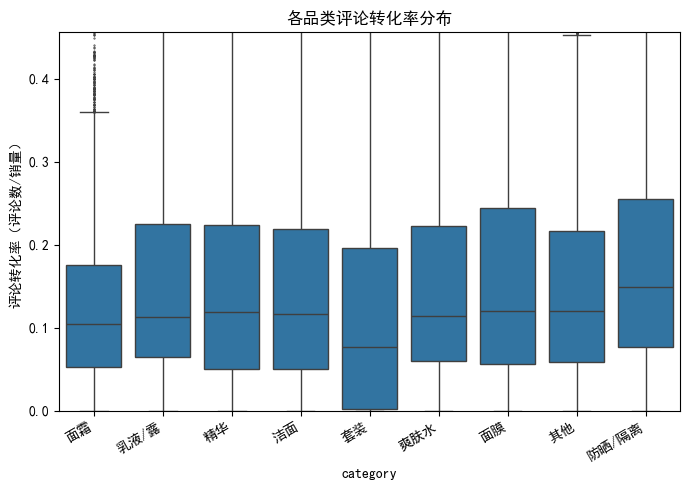

In [14]:
#在beauty_data中创建评论转化率列
beauty_data = beauty_data[beauty_data['sale_count'] > 0]
beauty_data['comment_rate'] = beauty_data['comment_count'] / beauty_data['sale_count']
beauty_data['comment_rate']=beauty_data['comment_count']/beauty_data['sale_count']
plt.figure(figsize=(7,5))
sns.boxplot(data=beauty_data, x='category', y='comment_rate', fliersize=0.5)
plt.ylim(0, beauty_data['comment_rate'].quantile(0.95))  # 去掉极端值，不然对箱线图影响很大
plt.title('各品类评论转化率分布')
plt.ylabel('评论转化率（评论数/销量）')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
#各品类评论转化率箱线图

In [15]:
#Kruscal-Wallis检验代码
beauty_data = beauty_data[beauty_data['sale_count'] > 0]
beauty_data['comment_rate'] = beauty_data['comment_count'] / beauty_data['sale_count']
categories = beauty_data['category'].unique()
groups = [beauty_data[beauty_data['category'] == cat]['comment_rate'].dropna() 
          for cat in categories if len(beauty_data[beauty_data['category'] == cat]) > 10]
h_stat, p_valu = stats.kruskal(*groups)
print(f"h值：{h_stat},p值：{p_valu}")

h值：489.7951352572543,p值：1.0876040115298888e-100


Kruscai-wallis检验的p值非常小，说明不同的品类之间评论转化率有显著差异。最后生成一个表格：

In [16]:
#因为在一些品类中有销量=0的产品，这使得求出的平均转化率无穷大，所以应去除：
beauty_data = beauty_data[beauty_data['sale_count'] > 0]
beauty_data['comment_rate'] = beauty_data['comment_count'] / beauty_data['sale_count']
comment_rate_by_cat = beauty_data.groupby('category').agg(
    平均转化率=('comment_rate', 'mean'),
    中位数转化率=('comment_rate', 'median'),
    样本量=('comment_rate', 'count')
).sort_values('平均转化率', ascending=False)
comment_rate_by_cat.to_excel('./comment_rate_by_cat.xlsx',index=False)
comment_rate_by_cat

,平均转化率,中位数转化率,样本量
category,,,
精华,2.515170,0.118644,2730
乳液/露,0.521786,0.113043,2541
防晒/隔离,0.496908,0.148565,1548
面膜,0.478982,0.120214,1308
面霜,0.359200,0.104460,3155
爽肤水,0.232993,0.114055,3138
其他,0.217757,0.119451,3779
洁面,0.190708,0.115945,2268
套装,0.131937,0.076205,4012


从表格和箱线图可以看出，中位数平均转化率最高的是防晒/隔离，而平均转化率最高的是精华，说明该品类中大多数产品的评论转化率普遍较高且分布较均匀，可能由于防晒产品的功效感知较明显：使用后是否清爽、等体验容易被消费者直观感受到，从而激发了普遍的评论意愿。而精华的平均转化率高的原因可能是由于其中有评论转化率极高的"爆款"，拉高了平均值，说明精华品类中大多数用户参与度不高，但有少数产品能激发用户的评论欲望。这就能说明为什么箱线图和表格表面上看起来不同的原因。

# 结论与建议
## 结论
本报告以2022年双十一期间淘宝美妆产品交易数据为对象，运用描述性统计、Spearman相关分析、Mann-Whitney U检验、Kruskal-Wallis检验等方法，系统分析了19个主要品牌的竞争格局、价格弹性的品类异质性以及评论转化率的差异特征。得出：

第一、双十一美妆市场呈现出三梯队竞争格局。基于品牌销售额、销量、平均价格及SKU丰富度多维度分析，可将19个品牌划分为三种竞争模式：以悦诗风吟、妮维雅、相宜本草为代表的"规模驱动型"品牌，依靠低价格与海量SKU占领大众市场；以娇兰、雪花秀、雅诗兰黛为代表的"价值驱动型"品牌，凭借高定价与精选产品对标高端客群；以欧莱雅、自然堂、佰草集为代表的"均衡发展型"品牌，则在规模与价值之间取得了相对平衡。从品类维度看，“水乳面霜”作为基础护肤刚需品类贡献了最高销售额占比，而“套装”品类以高客单价成为品牌拉升销售额的重要手段。

第二，价格弹性存在显著的品类异质性，精华品类呈现"倒U型"价格、销量关系。 Spearman相关分析表明，所有品类的价格与销量均呈显著负相关（p < 0.001），但相关系数绝对值从-0.58（防晒/隔离）到-0.38（乳液/露）不等，弹性强度存在明显梯度。结合价格区间箱线图的进一步分析识别出三种价格响应模式：洁面、面膜、爽肤水等基础品类属于“价格敏感型”，销量随价格上升而急剧下降；而防晒/隔离、面霜、乳液/露属于“价值锁定型”，在消费者心理舒适区内价格敏感度偏低；精华品类则呈现独特的“倒U型”关系——在0-50元低价区间销量低迷，50-100元区间销量反而达到峰值，平均销量从6027件升至28694件，增长接近5倍。进一步提供Mann-Whitney U检验证实了这一上升段差异的统计显著性（p <0.05）。该现象与Monroe（1973）提出的价格-质量推断理论一致：在信息不对称的功效型护肤品市场，过低的价格会向消费者传递负面质量信号，从而抑制购买意愿。

第三，评论转化率呈现品类间的显著差异，反映了消费者卷入度的结构性不同。Kruskal-Wallis检验表明，不同品类的评论转化率存在显著差异（p < 0.001）。防晒/隔离品类的评论转化率中位数居各品类之首（0.149），表明该品类的消费者具有普遍较高的评论意愿；而精华品类内部数据呈右偏分布，平均转化率受少数高值影响显著高于中位数，反映出精华市场中存在少数“爆款”产品集中获得大量评论的“头部效应”。高转化率产品相较低转化率产品具有更高的平均价格，进一步印证了高价产品消费者心理卷入度更高、评论动机更强的推论。
## 建议
第一、实施差异化的品类定价策略。 对于洁面、面膜等高价格弹性品类，大促期间应以有竞争力的价格折扣换取销量爆发，提高市场份额，也就是所谓的薄利多销；对于精华、套装等低弹性品类，则应警惕盲目降价进入极端低价区间。特别是精华品类，0-50元区间的销量惨淡，这提示品牌方：功效型产品存在消费者的心理价格下限，维持该下限对于保护品牌信任与品质感知至关重要，切记不要把价格降低到下限水平，反而会使销量减少。

第二、优化口碑激励资源的投放方向。 防晒/隔离、精华等评论转化率较高的品类是口碑营销的天然价值洼地，品牌可通过赠品激励、会员专属评价、使用体验分享等方式进一步放大用户评论意愿。对于评论转化率较低的品类如套装，则需反思是否存在评论激励机制设计不够精准的问题，或者把注意力集中在套装的组合价值上面来，通过更好的搭配来提升销售额。

第三、明确自身竞争定位，选择适配的品牌战略。 通过气泡图显示，头部品牌已形成清晰的差异化定位。中小品牌或新进入者应根据自身资源禀赋，在“规模驱动”与“价值驱动”之间做出明确选择，选择自己的顾客是高收入群体还是低收入群体，避免陷入定位模糊、两头不靠的困境。

## 不足与展望
本数据集仅覆盖2022年双十一前后单一时间节点，属于截面数据，无法捕捉品牌竞争格局和消费者行为的季节性变化与年度趋势。未来可引入多年双十一数据或多期日常销售数据，构建面板数据模型，动态分析价格弹性和口碑效应的时序演化。另外、本研究缺乏用户画像（年龄、性别、消费层级）、订单明细以及商品详情页浏览记录等深层信息，不能分析不同群体的消费差异，也无法深入分析评论转化率差异背后的个体行为动因，若能得到用户画像，后序还可进一步进行推荐系统的构建。而且本研究对商品品类的划分依赖于title字段的关键词匹配规则，可能存在少量产品的错误分类（如“精华水”被归入精华品类）。未来研究可结合平台提供的标准品类标签或产品信息，进一步提升品类划分的准确性，从而提高分析的精确度。

而在数据分析方法的选择上，本研究优先采用Spearman相关分析、Mann-Whitney U检验及Kruskal-Wallis检验等非参数方法，而不使用统计回归等参数模型。这一选择基于以下考量：

一，数据分布的客观约束。 电商交易数据中的销量与评论数呈现典型的右偏分布，即少数爆款产品具有极高销量，大多数产品销量相对较低，甚至为0，不满足线性回归模型对残差正态性与方差齐性的基本假设。若强行套用参数模型，可能导致显著性检验失真，得出误导性结论。
二，研究问题的本质特征区别。 本研究的核心目标是“比较”而非“预测”——比较不同品类的价格弹性、比较不同品类的评论转化率。对于这类多组比较问题，非参数检验是更直接和稳健的分析方法，而且数据有两万多条，得到的回归分析结果似乎也不能进行预测。
三，方法适配性优于方法复杂度。 数据分析中不存在绝对“高级”的方法，只有最适合研究问题与数据特征的方法。Spearman相关分析能够捕捉价格与销量之间的单调关系且不限于线性关系，使研究中发现了“倒U型”等非线性模式。

# 收获与反思
回顾本次分析的全过程，从数据清洗到宏观描述，从描述统计到假设检验，每一步都伴随着方法的选择与权衡。最初接触这份双十一美妆数据时，也曾犹豫是否应当采用回归分析、聚类算法等更为“复杂”的方法，以体现分析的“高级”。但随着分析的深入，我逐渐知道，对于不同的数据集要使用相适应的方法，因为数据分析的最终目的是为决策者提供理论支撑。

我们不仅要把一个复杂的数据集变成一个漂亮、精炼的数据表，还需要知道其背后的原因，了解数据为什么是这样分布的，比如说文中的"精华"品类价格与销量为什么呈现U型，其背后的经济理论是什么，这样分析的数据才有意义，才能运用到实际中来。从这个意义上说，本次研究带给我的不仅是技术层面的锻炼，更是一次数据分析思维范式的重塑：“合适”远比“复杂”更重要，“有用”远比“花哨”更重要，这是我在完成数据分析报告过程中学到的最重要的一课。


# 参考文献
[1] :Monroe, K. B. (1973). Buyers' subjective perceptions of price. Journal ofMarketing Research, 10(1), 70-80.

[2]:Rao, A.R.,& Monroe, K. B. (1989). The effect of price, brand name, and store name on buyers' perceptions of product quality: An integrative review.Journal of Marketing Research, 26(3), 351-357.

[3]:Veblen,T.(1899). The Theory of the Leisure Class. New York: Macmillan.